# Notebook 05 (No Augmentation, No CV) — PLS-DA and SVM with 80/20 Stratified Split
## CMSC 190 Special Problem — NIR Maize Protein Classifier

**Purpose:** Train and evaluate PLS-DA and SVM classifiers for High-Protein vs Low-Protein corn classification using NIR spectral data, **without any data augmentation and without cross-validation**.

This notebook is a variant of `revised_no_augmentation/05_plsda_svm_no_aug.ipynb`. The 5-fold outer CV loop is replaced with a single stratified 80/20 train/test split.

### Evaluation Strategy: Single 80/20 Stratified Split
- The full dataset of **80 samples** is split once into **64 training samples (80%)** and **16 test samples (20%)**
- Stratification ensures the 50/50 High-Protein / Low-Protein class ratio is preserved in both sets
- **No augmentation is applied** — models are trained on the raw 64 training samples
- Hyperparameters are tuned using a single inner holdout from the training set (no inner CV loop)
- Final metrics are single values (no mean +/- std)

---
## Section 1 — Imports and Setup

In [ ]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import joblib

from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedShuffleSplit, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

sys.path.append('../..')

from src.trainer import plot_confusion_matrix

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_theme(style='whitegrid', palette='muted')

random_state = 42

print('All libraries imported successfully.')
print(f'random_state set to {random_state}')
print('NOTE: No augmentation, no CV — single 80/20 stratified split.')


All libraries imported successfully.
random_state set to 42
NOTE: No augmentation, no CV — single 80/20 stratified split.


---
## Section 2 — Load Full Dataset

In [2]:
X = np.load('../../data/processed/X_preprocessed.npy')
y = np.load('../../data/processed/y_labels.npy')

print('Dataset loaded successfully.')
print(f'X shape : {X.shape}   (samples x wavelength features)')
print(f'y shape : {y.shape}   (binary labels)')

print('\nClass distribution:')
classes, counts = np.unique(y, return_counts=True)
labels_map = {0: 'Low Protein  (0)', 1: 'High Protein (1)'}
for cls, cnt in zip(classes, counts):
    print(f'  {labels_map[cls]} : {cnt} samples ({cnt/len(y)*100:.1f}%)')

Dataset loaded successfully.
X shape : (549, 700)   (samples x wavelength features)
y shape : (549,)   (binary labels)

Class distribution:
  Low Protein  (0) : 255 samples (46.4%)
  High Protein (1) : 294 samples (53.6%)


---
## Section 3 — 80/20 Stratified Train/Test Split

A single stratified split divides the 80 samples into **64 training (80%)** and **16 test (20%)**.
Stratification preserves the 50/50 class ratio in both sets.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state, stratify=y
)

print('Train/Test Split Results')
print(f'  Training samples : {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Test samples     : {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.0f}%)')
print()
print('Training class distribution:')
for cls, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f'  Class {int(cls)} : {cnt} samples')
print('Test class distribution:')
for cls, cnt in zip(*np.unique(y_test, return_counts=True)):
    print(f'  Class {int(cls)} : {cnt} samples')

Train/Test Split Results
  Training samples : 439 (80%)
  Test samples     : 110 (20%)

Training class distribution:
  Class 0 : 204 samples
  Class 1 : 235 samples
Test class distribution:
  Class 0 : 51 samples
  Class 1 : 59 samples


---
## Section 4 — PLS-DA (No Augmentation, 80/20 Split)

**Partial Least Squares Discriminant Analysis (PLS-DA)** is trained on the 64 raw training samples.

The number of latent components (`n_components`) is selected using **5-fold stratified cross-validation**
on the training set, testing values 1 to 30 and choosing the one with the highest mean validation F1-score.


### 4a — PLS-DA Training

Inner holdout: 329 train / 110 val
Selected n_components = 22  (inner val F1 = 0.8571)

  PLS-DA Results (80/20 split, No Augmentation)
  Accuracy  : 0.8909
  Precision : 0.8615
  Recall    : 0.9492
  F1-Score  : 0.9032


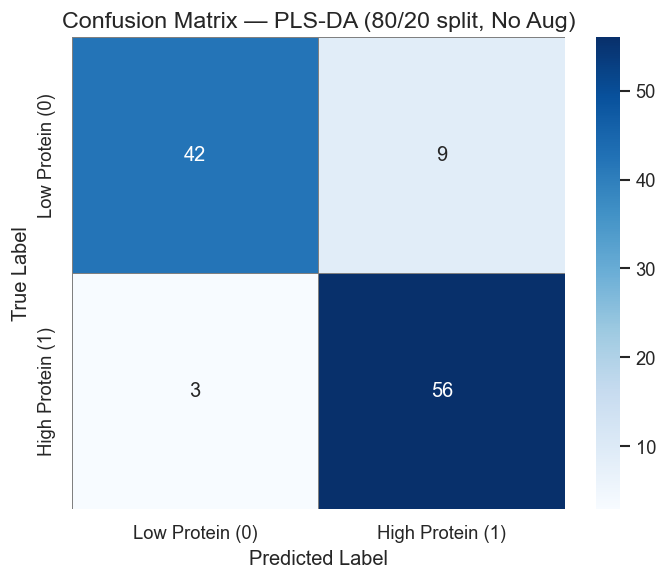

In [ ]:
# 5-fold stratified CV on training set for n_components selection
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

candidate_scores = []
for n in range(1, 31):
    fold_f1s = []
    for train_idx, val_idx in inner_cv.split(X_train, y_train):
        X_tr_inner, X_val_inner = X_train[train_idx], X_train[val_idx]
        y_tr_inner, y_val_inner = y_train[train_idx], y_train[val_idx]

        pls_candidate = PLSRegression(n_components=n)
        pls_candidate.fit(X_tr_inner, y_tr_inner)
        y_val_pred = (pls_candidate.predict(X_val_inner).ravel() >= 0.5).astype(int)
        fold_f1s.append(f1_score(y_val_inner, y_val_pred, zero_division=0))

    candidate_scores.append(np.mean(fold_f1s))

best_n = int(np.argmax(candidate_scores)) + 1
print(f'Selected n_components = {best_n}  (5-fold CV mean F1 = {max(candidate_scores):.4f})')

# Train final PLS-DA on all 64 training samples
plsda = PLSRegression(n_components=best_n)
plsda.fit(X_train, y_train)

# Evaluate on held-out test set
y_pred_plsda = (plsda.predict(X_test).ravel() >= 0.5).astype(int)

plsda_acc  = accuracy_score(y_test, y_pred_plsda)
plsda_prec = precision_score(y_test, y_pred_plsda, zero_division=0)
plsda_rec  = recall_score(y_test, y_pred_plsda, zero_division=0)
plsda_f1   = f1_score(y_test, y_pred_plsda, zero_division=0)

print('\n============================================')
print('  PLS-DA Results (80/20 split, No Augmentation)')
print('============================================')
print(f'  Accuracy  : {plsda_acc:.4f}')
print(f'  Precision : {plsda_prec:.4f}')
print(f'  Recall    : {plsda_rec:.4f}')
print(f'  F1-Score  : {plsda_f1:.4f}')
print('============================================')

plot_confusion_matrix(y_test, y_pred_plsda, model_name='PLS-DA (80/20 split, No Aug)')


### 4b — Save PLS-DA Model

In [5]:
os.makedirs('../../saved_models/revised_no_augmentation_no_cv', exist_ok=True)

plsda_bundle = {
    'model': plsda,
    'scaler': None,
    'model_type': 'PLS-DA'
}
joblib.dump(plsda_bundle, '../../saved_models/revised_no_augmentation_no_cv/pls_da_best.pkl')
print('PLS-DA model saved to: saved_models/revised_no_augmentation_no_cv/pls_da_best.pkl')
print(f'F1-score: {plsda_f1:.4f}')

PLS-DA model saved to: saved_models/revised_no_augmentation_no_cv/pls_da_best.pkl
F1-score: 0.9032


---
## Section 5 — SVM (No Augmentation, 80/20 Split)

**Support Vector Machine (SVM)** with an RBF kernel trained on the 64 raw training samples.
`StandardScaler` is fitted on the training set only. Hyperparameters `C` and `gamma` are
selected via `GridSearchCV` using a **single inner holdout** (`StratifiedShuffleSplit` with
`n_splits=1, test_size=0.25`) rather than a full inner CV loop.

### 5a — SVM Training

Best SVM params: {'C': 32768, 'gamma': 0.0001220703125, 'kernel': 'rbf'}

   SVM Results (80/20 split, No Augmentation)
  Accuracy  : 0.8727
  Precision : 0.8358
  Recall    : 0.9492
  F1-Score  : 0.8889


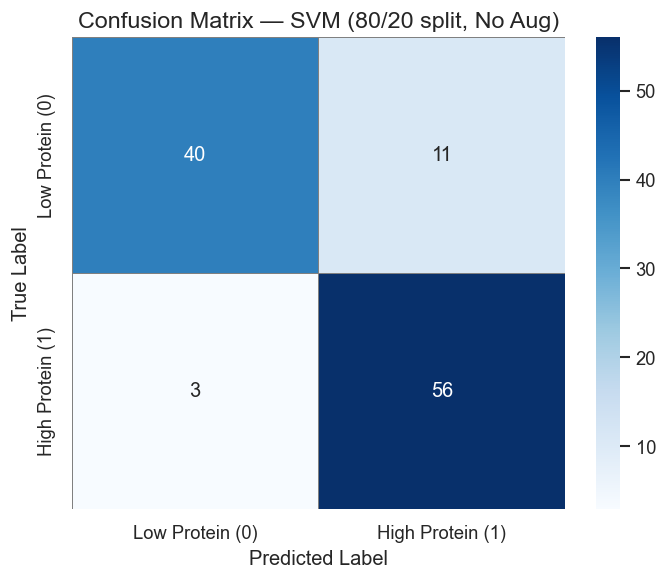

In [6]:
# Scale — fit on training set only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

param_grid = {
    'C':      [2**i for i in range(-5, 16)],   # 2^-5 to 2^15 (step by 2)
    'gamma':  [2**i for i in range(-15, 4)],   # 2^-15 to 2^3 (step by 2)
    # 'C':      [0.1, 1, 10, 100],
    # 'gamma':  ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf'],
}

# Single inner holdout for hyperparameter tuning (no CV loop)
inner_cv = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=random_state)
grid = GridSearchCV(
    SVC(random_state=random_state),
    param_grid,
    cv=inner_cv,
    scoring='f1',
    n_jobs=-1,
)
grid.fit(X_train_scaled, y_train)
print(f'Best SVM params: {grid.best_params_}')

# Retrain on all 64 scaled training samples with best params
svm = SVC(**grid.best_params_, random_state=random_state)
svm.fit(X_train_scaled, y_train)

# Evaluate on test set
y_pred_svm = svm.predict(X_test_scaled)

svm_acc  = accuracy_score(y_test, y_pred_svm)
svm_prec = precision_score(y_test, y_pred_svm, zero_division=0)
svm_rec  = recall_score(y_test, y_pred_svm, zero_division=0)
svm_f1   = f1_score(y_test, y_pred_svm, zero_division=0)

print('\n============================================')
print('   SVM Results (80/20 split, No Augmentation)')
print('============================================')
print(f'  Accuracy  : {svm_acc:.4f}')
print(f'  Precision : {svm_prec:.4f}')
print(f'  Recall    : {svm_rec:.4f}')
print(f'  F1-Score  : {svm_f1:.4f}')
print('============================================')

plot_confusion_matrix(y_test, y_pred_svm, model_name='SVM (80/20 split, No Aug)')

### 5b — Save SVM Model

In [7]:
svm_bundle = {
    'model': svm,
    'scaler': scaler,
    'model_type': 'SVM'
}
joblib.dump(svm_bundle, '../../saved_models/revised_no_augmentation_no_cv/svm_best.pkl')
print('SVM model saved to: saved_models/revised_no_augmentation_no_cv/svm_best.pkl')
print(f'F1-score: {svm_f1:.4f}')

SVM model saved to: saved_models/revised_no_augmentation_no_cv/svm_best.pkl
F1-score: 0.8889


---
## Section 6 — Compare PLS-DA vs SVM

,Accuracy,Precision,Recall,F1-Score
Model,,,,
PLS-DA,0.8909,0.8615,0.9492,0.9032
SVM,0.8727,0.8358,0.9492,0.8889


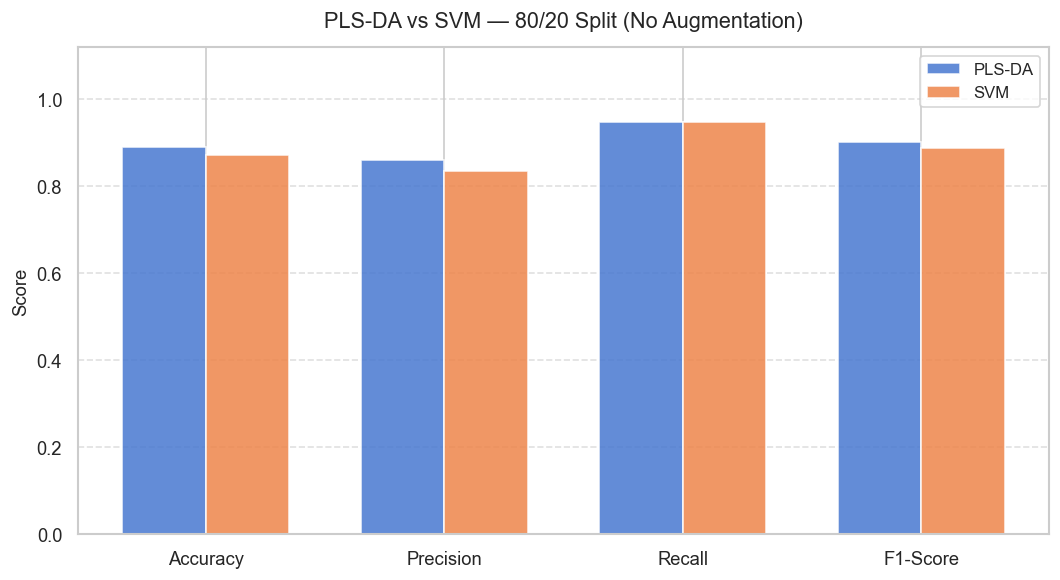

  PLS-DA F1 : 0.9032
  SVM    F1 : 0.8889
  Better model : PLS-DA (delta F1 = 0.0143)


In [8]:
comparison_df = pd.DataFrame([
    {'Model': 'PLS-DA', 'Accuracy': plsda_acc, 'Precision': plsda_prec, 'Recall': plsda_rec, 'F1-Score': plsda_f1},
    {'Model': 'SVM',    'Accuracy': svm_acc,   'Precision': svm_prec,   'Recall': svm_rec,   'F1-Score': svm_f1},
])
display(comparison_df.set_index('Model').round(4))

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
plsda_vals   = [plsda_acc, plsda_prec, plsda_rec, plsda_f1]
svm_vals     = [svm_acc,   svm_prec,   svm_rec,   svm_f1]

x      = np.arange(len(metric_names))
width  = 0.35
colors = sns.color_palette('muted', 2)

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, plsda_vals, width, label='PLS-DA', color=colors[0], alpha=0.85)
bars2 = ax.bar(x + width/2, svm_vals,   width, label='SVM',    color=colors[1], alpha=0.85)

ax.set_title('PLS-DA vs SVM — 80/20 Split (No Augmentation)', fontsize=13, pad=12)
ax.set_ylabel('Score', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

better_model = 'SVM' if svm_f1 >= plsda_f1 else 'PLS-DA'
margin       = abs(svm_f1 - plsda_f1)
print('============================================')
print(f'  PLS-DA F1 : {plsda_f1:.4f}')
print(f'  SVM    F1 : {svm_f1:.4f}')
print(f'  Better model : {better_model} (delta F1 = {margin:.4f})')
print('============================================')

---
## Section 7 — Save Results to Disk

Results are saved to `data/results/no_aug_no_cv/` so that notebook 07 can load them without retraining.

In [9]:
import json

os.makedirs('../../data/results/no_aug_no_cv', exist_ok=True)

plsda_results = {
    'model':     'PLS-DA',
    'accuracy':  float(plsda_acc),
    'precision': float(plsda_prec),
    'recall':    float(plsda_rec),
    'f1':        float(plsda_f1),
    'y_true':    [int(v) for v in y_test],
    'y_pred':    [int(v) for v in y_pred_plsda],
}
with open('../../data/results/no_aug_no_cv/plsda_results.json', 'w') as f:
    json.dump(plsda_results, f, indent=2)
print('PLS-DA results saved to: data/results/no_aug_no_cv/plsda_results.json')

svm_results = {
    'model':     'SVM',
    'accuracy':  float(svm_acc),
    'precision': float(svm_prec),
    'recall':    float(svm_rec),
    'f1':        float(svm_f1),
    'y_true':    [int(v) for v in y_test],
    'y_pred':    [int(v) for v in y_pred_svm],
}
with open('../../data/results/no_aug_no_cv/svm_results.json', 'w') as f:
    json.dump(svm_results, f, indent=2)
print('SVM results saved to: data/results/no_aug_no_cv/svm_results.json')

PLS-DA results saved to: data/results/no_aug_no_cv/plsda_results.json
SVM results saved to: data/results/no_aug_no_cv/svm_results.json
